In [17]:
import random
import requests
from datetime import datetime
import time
import os
from dotenv import load_dotenv
import pandas as pd
import logging
from pathlib import Path
from tqdm import tqdm
from sqlalchemy import create_engine

load_dotenv()
log_path = Path("/app/logs/error.log")
log_path.parent.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler()
    ],
    force=True,
)

ACCOUNT = os.getenv('STOCK_ACCOUNT_USERNAME')
PASSWORD = os.getenv('STOCK_ACCOUNT_PASSWORD')
PG_URI = os.getenv('POSTGRES_URI')

In [18]:
import sys
from pathlib import Path

workspace_root = Path("/app")
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from trade.stock_api import get_taiwan_stock_data, get_twse_stock_data

## 01 Stock overview

In [3]:
stock_info = pd.read_json('http://140.116.86.242:8081/api/stock/get_stock_list')
stock_info.head()

,result,data
0,success,"{'code': '0050', 'name': '元大台灣50', 'listing_ti..."
1,success,"{'code': '0051', 'name': '元大中型100', 'listing_t..."
2,success,"{'code': '0052', 'name': '富邦科技', 'listing_time..."
3,success,"{'code': '0053', 'name': '元大電子', 'listing_time..."
4,success,"{'code': '0054', 'name': '元大台商50', 'listing_ti..."


In [4]:
import requests
from requests.exceptions import JSONDecodeError

def safe_get_json(url: str, timeout: int = 15):
    """Fetch URL and parse JSON safely with clear diagnostics."""
    try:
        resp = requests.get(url, timeout=timeout)
    except requests.RequestException as e:
        print(f"Request failed: {e}")
        return None

    print(f"HTTP {resp.status_code} | Content-Type: {resp.headers.get('Content-Type', 'N/A')}")

    if not resp.text or not resp.text.strip():
        print("Empty response body (this is the common cause of JSONDecodeError at char 0).")
        return None

    try:
        return resp.json()
    except JSONDecodeError:
        print("Response is not valid JSON. First 500 chars:")
        print(resp.text[:500])
        return None

stock_list_url = 'http://140.116.86.242:8081/api/stock/get_stock_list'
stock_list_json = safe_get_json(stock_list_url)

if stock_list_json is not None:
    stock_info = pd.DataFrame(stock_list_json)
    stock_info.head()

HTTP 200 | Content-Type: application/json; charset=utf-8


### 01-0 FinMind API

In [19]:
from FinMind.data import DataLoader

api = DataLoader()
# api.login_by_token(api_token='token')
df = api.taiwan_stock_info_with_warrant()
df.head()

2026-06-09 16:02:52.183 | INFO     | FinMind.data.finmind_api:login_by_token:85 - Login success
2026-06-09 16:02:52.184 | INFO     | FinMind.data.finmind_api:get_data:164 - download Dataset.TaiwanStockInfoWithWarrant, data_id: 


,industry_category,stock_id,stock_name,type,date
0,封閉式基金,0001,鴻運,twse,2024-12-05
1,封閉式基金,0002,福元,twse,2024-12-05
2,封閉式基金,0003,成長,twse,2024-12-05
3,封閉式基金,0004,國民,twse,2024-12-05
4,封閉式基金,0005,成功,twse,2024-12-05


In [20]:
# 三大法人
api = DataLoader()
# api.login_by_token(api_token='token')
df = api.taiwan_stock_institutional_investors(
    stock_id_list=['2330', '2317', '2454', '3008'],
    start_date='2020-01-01',
    end_date='2020-04-12',
    use_async=True
)
df_pivot = df.pivot_table(
    index=['date', 'stock_id'],
    columns='name',
    values=['buy', 'sell'],
    aggfunc='first'
)
df_pivot.columns = [f'{val}_{name}' for val, name in df_pivot.columns]
print(df_pivot.shape)
df_pivot = df_pivot.reset_index()
df_pivot.head()

2026-06-09 16:02:55.627 | INFO     | FinMind.data.finmind_api:login_by_token:85 - Login success
2026-06-09 16:02:55.628 | INFO     | FinMind.data.finmind_api:_get_data_with_async:201 - download Dataset.TaiwanStockInstitutionalInvestorsBuySell, data_id: ['2330', '2317', '2454', '3008']
100%|██████████| 4/4 [00:00<00:00, 17.94it/s]

(248, 10)


,date,stock_id,buy_Dealer_Hedging,buy_Dealer_self,buy_Foreign_Dealer_Self,buy_Foreign_Investor,buy_Investment_Trust,sell_Dealer_Hedging,sell_Dealer_self,sell_Foreign_Dealer_Self,sell_Foreign_Investor,sell_Investment_Trust
0,2020-01-02,2317,1053000,341000,0,4568000,925000,371000,268000,0,8304375,60000
1,2020-01-02,2330,217000,475000,0,13041781,20000,308000,401000,0,17798488,199000
2,2020-01-02,2454,194000,120000,0,1203625,0,20000,75000,0,2610640,1034000
3,2020-01-02,3008,6000,13000,0,137000,0,0,6000,0,136447,1000
4,2020-01-03,2317,1507000,210000,0,14922022,971000,803000,260000,0,9744734,45000


In [ ]:
# 融資融券
api = DataLoader()
# api.login_by_token(api_token='token')

# start = datetime.datetime.now()
df_short = api.taiwan_stock_margin_purchase_short_sale(
    stock_id_list=['2330', '2317', '2454', '3008'],
    start_date='2024-01-01',
    end_date='2024-12-31',
    use_async=True,
)
df_short.head()

2026-06-09 16:07:11.826 | INFO     | FinMind.data.finmind_api:login_by_token:85 - Login success
2026-06-09 16:07:11.828 | INFO     | FinMind.data.finmind_api:_get_data_with_async:201 - download Dataset.TaiwanStockMarginPurchaseShortSale, data_id: ['2330', '2317', '2454', '0050']
100%|██████████| 4/4 [00:00<00:00, 15.52it/s]


,date,stock_id,MarginPurchaseBuy,MarginPurchaseCashRepayment,MarginPurchaseLimit,MarginPurchaseSell,MarginPurchaseTodayBalance,MarginPurchaseYesterdayBalance,Note,OffsetLoanAndShort,ShortSaleBuy,ShortSaleCashRepayment,ShortSaleLimit,ShortSaleSell,ShortSaleTodayBalance,ShortSaleYesterdayBalance
0,2024-01-02,2454,592,2,399911,342,6230,5982,X,0,0,0,399911,0,0,0
1,2024-01-03,2454,670,3,399911,461,6436,6230,,0,0,0,399911,0,0,0
2,2024-01-04,2454,554,3,399911,201,6786,6436,,34,0,0,399911,27,27,0
3,2024-01-05,2454,235,1,399911,134,6886,6786,,11,12,0,399911,4,19,27
4,2024-01-08,2454,220,1,399911,100,7005,6886,,0,0,0,399911,14,33,19


In [24]:
df_pivot.columns

Index(['date', 'stock_id', 'buy_Dealer_Hedging', 'buy_Dealer_self',
       'buy_Foreign_Dealer_Self', 'buy_Foreign_Investor',
       'buy_Investment_Trust', 'sell_Dealer_Hedging', 'sell_Dealer_self',
       'sell_Foreign_Dealer_Self', 'sell_Foreign_Investor',
       'sell_Investment_Trust'],
      dtype='object')

/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N

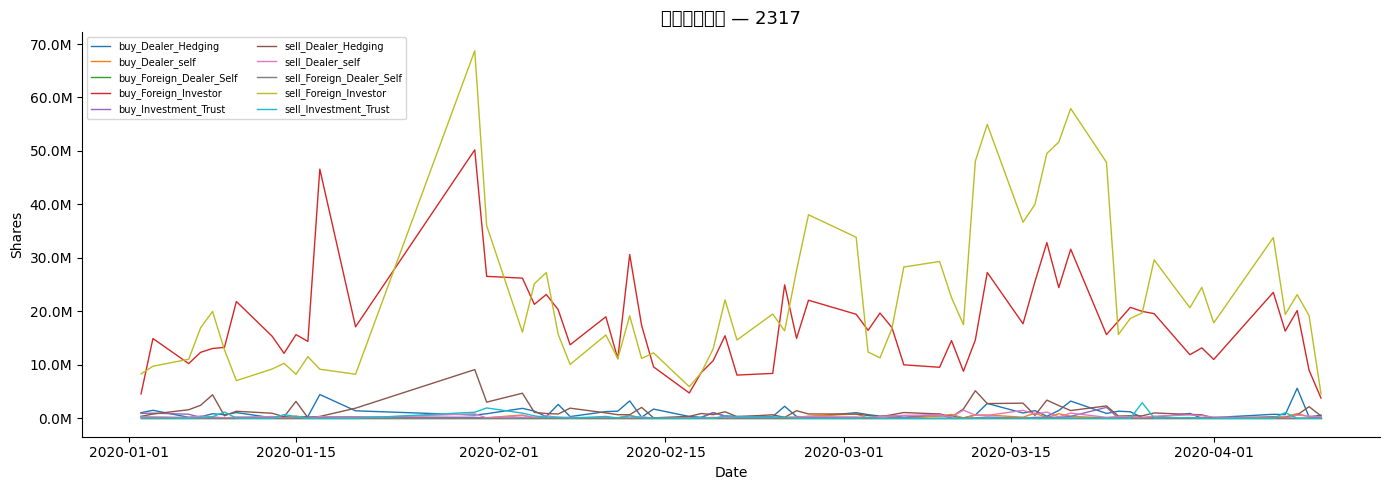

/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N

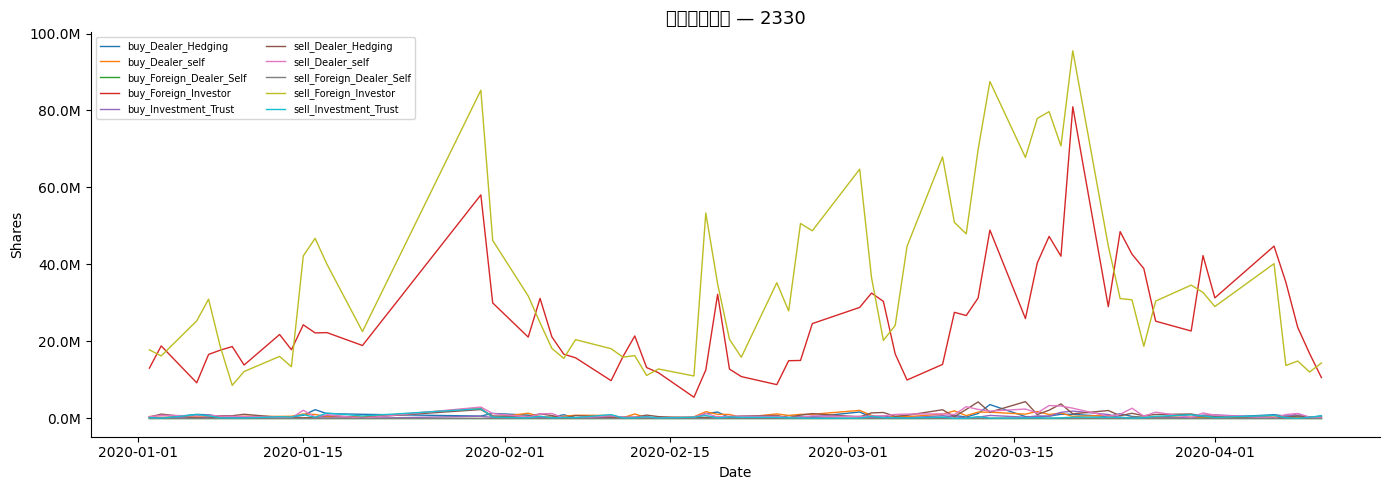

/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N

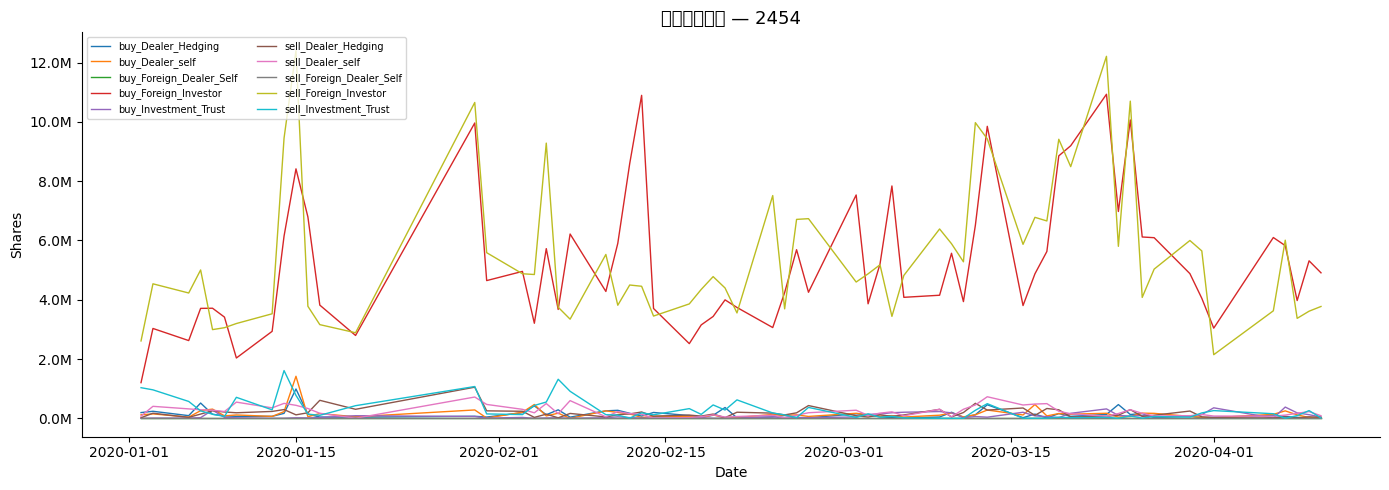

/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3254/427799648.py:23: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N

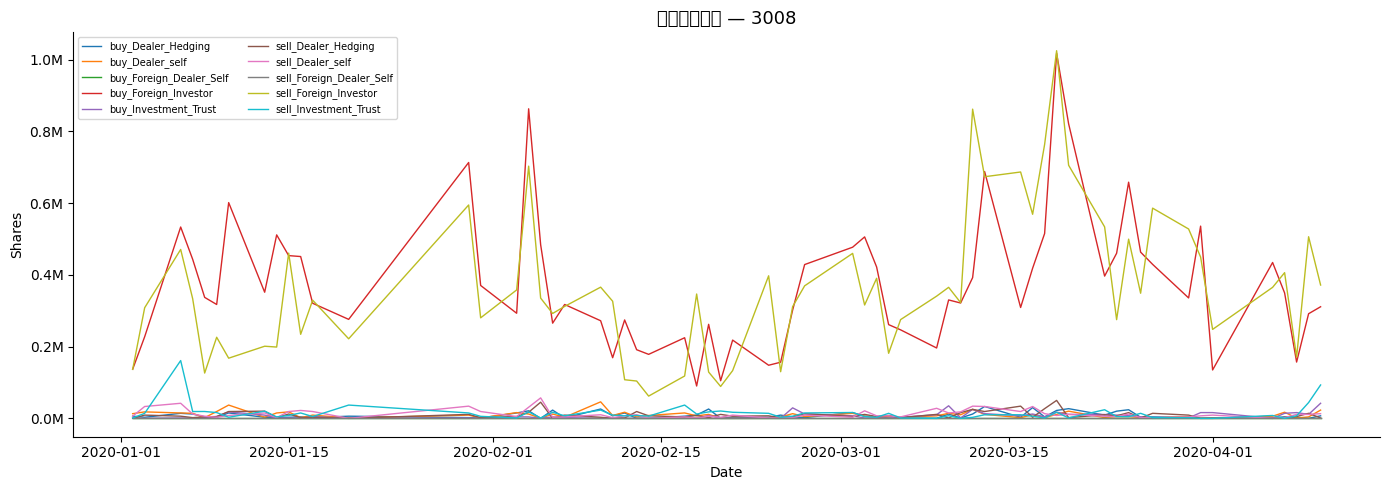

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

feature_cols = [c for c in df_pivot.columns if c not in ('date', 'stock_id')]
stock_ids = df_pivot['stock_id'].unique()

for sid in stock_ids:
    sub = df_pivot[df_pivot['stock_id'] == sid].copy()
    sub['date'] = pd.to_datetime(sub['date'])
    sub = sub.sort_values('date')

    fig, ax = plt.subplots(figsize=(14, 5))
    for col in feature_cols:
        ax.plot(sub['date'], sub[col], label=col, linewidth=1)

    ax.set_title(f'三大法人買賣 — {sid}', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Shares')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(loc='upper left', fontsize=7, ncol=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


In [6]:
print(df['industry_category'].unique())

['封閉式基金' 'ETF' '全部(不含大盤、指數、權證、牛熊證、可展延牛熊證)' '全部(不含大盤、指數)' '上櫃ETF'
 '上櫃指數股票型基金(ETF)' '受益證券' 'ETN' '指數投資證券(ETN)' '認購權證(不含牛證)' '熊證(不含可展延熊證)'
 '牛證(不含可展延牛證)' '認售權證(不含熊證)' '可展延牛證' '水泥工業' '其他' '食品工業' '電器電纜' '農業科技業'
 '觀光事業' '觀光餐旅' '塑膠工業' '建材營造' '汽車工業' '電子零組件類' '紡織纖維' '貿易百貨' '運動休閒' '電子工業'
 '電子零組件業' '電機機械' '可轉換公司債' '生技醫療類' '電腦及週邊類' '運動休閒類' '化學生技醫療' '生技醫療業' '化學工業'
 '其他電子類' '玻璃陶瓷' '造紙工業' '鋼鐵工業' '居家生活' '綠能環保' '橡膠工業' '航運業' '創新板股票' '創新版股票'
 '電腦及週邊設備業' '半導體業' '其他電子業' '通信網路業' '光電業' '電子通路業' '資訊服務業' '油電燃氣業' '數位雲端類'
 '金融保險' '居家生活類' '文化創意業' '光電業類' '半導體類' '綠能環保類' '通信網路類' '電子商務業' '數位雲端'
 '資訊服務類' '電子通路類' '金融業' '認購售權證' '牛熊證(不含展延型牛熊證)' '油電燃氣類' '存託憑證']


In [7]:
# df.to_sql(name='stock_info', con=PG_URI, if_exists='replace', index=False)

### 01-1 Filter out low liquidity stocks
- Focus on twse type stocks
- Focus on normal industry stocks and ETFs
- Remove the stocks with low transaction volumes (Use 2026 Feb monthly transaction volume) 
(https://openapi.twse.com.tw/v1/exchangeReport/FMSRFK_ALL)

In [8]:
target_categories = [
    'ETF', '水泥工業', '食品工業', 
    '電器電纜', '農業科技業', '觀光餐旅', '塑膠工業', '建材營造', 
    '汽車工業', '電子零組件業', '紡織纖維', '貿易百貨', '運動休閒', 
    '電子工業', '電機機械', '生技醫療業', '電腦及週邊設備業', '化學工業', 
    '其他電子業', '玻璃陶瓷', '造紙工業', '鋼鐵工業', '居家生活', 
    '橡膠工業', '航運業', '半導體業', '通信網路業', '光電業', 
    '電子通路業', '資訊服務業', '油電燃氣業', '數位雲端', '金融保險', 
    '文化創意業', '綠能環保', '電子商務業'
]
target_type = ['twse']
filter_df = df[df['industry_category'].isin(target_categories) & df['type'].isin(target_type)]
print(df.shape, filter_df.shape)

(182729, 5) (1981, 5)


In [9]:
# Filter out stocks with low liquidity
def filter_liquidity(trade_vol_share: int = 100*1000, trade_value_ntd: int = 5000000) -> pd.DataFrame:
    """
    This function filters out stocks that do not meet the specified liquidity criteria.
    Stocks must have a daily trading volume greater than `trade_vol_share` shares or a daily
    trading value greater than `trade_value_ntd` NTD.   
    
    The data is fetched from the Taiwan Stock Exchange (TWSE) API(上市個股月成交資訊), which provides the last month's trading volume 
    and value for all listed stocks. The function processes this data to identify stocks that meet the liquidity 
    requirements and returns a DataFrame containing the filtered stocks.
    """
    # Fetch data and preprocess
    try:
        month_stock_vol = pd.read_json('https://openapi.twse.com.tw/v1/exchangeReport/FMSRFK_ALL')
        month_stock_vol.columns = month_stock_vol.columns.str.lower()
        print(f"Original shape: {month_stock_vol.shape}")

        for col in ['tradevolumeb', 'tradevaluea']:
            month_stock_vol[col] = month_stock_vol[col].astype(str).str.replace(',', '').astype(float)
        filter_vol = month_stock_vol['tradevolumeb'] >= trade_vol_share
        filter_value = month_stock_vol['tradevaluea'] >= trade_value_ntd
        filtered_stocks = month_stock_vol[filter_vol & filter_value]
        print(f"Filtered shape: {filtered_stocks.shape}")
        return filtered_stocks
    except Exception as e:
        print(f"Error fetching or processing data: {e}")
        return pd.DataFrame()
    
filtered_stocks = filter_liquidity()
# filtered_stocks.to_sql(name='high_liquidity_stocks', con=PG_URI, if_exists='replace', index=False)
filtered_stocks.head()

Original shape: (29373, 10)
Filtered shape: (5971, 10)


,month,code,name,highestprice,lowestprice,weightedavgpriceab,transaction,tradevaluea,tradevolumeb,turnoverratio
0,11504,00400A,主動國泰動能高息,13.05,10.75,12.01,322520,2.302100e+10,1.915862e+09,131.66
1,11504,00401A,主動摩根台灣鑫收,12.15,10.50,11.20,45015,4.071572e+09,3.634575e+08,132.94
2,11504,0050,元大台灣50,94.25,73.80,84.08,2337163,1.975080e+11,2.348836e+09,12.69
3,11504,0051,元大中型100,127.40,107.50,119.67,17487,2.853685e+08,2.384613e+06,9.73
4,11504,0052,富邦科技,55.55,43.73,50.04,582412,5.445830e+10,1.088276e+09,43.28


In [10]:
final_df = filter_df[filter_df['stock_id'].isin(filtered_stocks['code'])].reset_index(drop=True)
final_df['date'] = pd.to_datetime(final_df['date']).dt.date
final_df.to_sql(name='targeted_stock_info', con=PG_URI, if_exists='replace', index=False)
final_df.head()

,industry_category,stock_id,stock_name,type,date
0,ETF,00400A,主動國泰動能高息,twse,2026-05-19
1,ETF,00401A,主動摩根台灣鑫收,twse,2026-05-19
2,ETF,0050,元大台灣50,twse,2026-05-19
3,ETF,0051,元大中型100,twse,2026-05-19
4,ETF,0052,富邦科技,twse,2026-05-19


In [11]:
df_top10_industries = final_df.value_counts('industry_category').sort_values(ascending=False).reset_index(name='count').head(10)
top10_industries_list = df_top10_industries['industry_category'].tolist()
df_top10_industries


,industry_category,count
0,電子工業,457
1,ETF,217
2,電子零組件業,104
3,半導體業,95
4,光電業,70
5,電腦及週邊設備業,66
6,生技醫療業,60
7,建材營造,55
8,電機機械,50
9,金融保險,49


/tmp/ipykernel_8892/2298366958.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_top10_industries['industry_category'], rotation=45, ha='right')


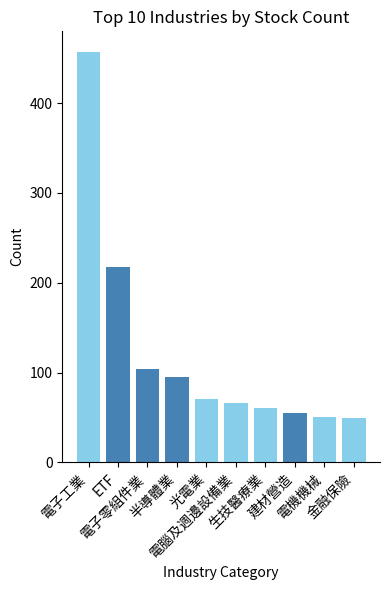

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Noto Sans CJK SC'
plt.rcParams['axes.unicode_minus'] = False
high_light = ['ETF',  '建材營造', '電子零組件業', '半導體業', '通信網路業']
colors = ['skyblue' if industry not in high_light else 'steelblue' for industry in df_top10_industries['industry_category']]

# plot top 10 industries and their counts
fig, ax = plt.subplots(figsize=(4, 6))
ax.bar(df_top10_industries['industry_category'], df_top10_industries['count'], color=colors)
ax.set_xlabel('Industry Category')
ax.set_ylabel('Count')
ax.set_title('Top 10 Industries by Stock Count')
ax.set_xticklabels(df_top10_industries['industry_category'], rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 01-2 Filter transaction value top 5 stocks of each industry

In [18]:
import json

TOP_STOCK_NUM = 10

mapping_df = df[['stock_id', 'industry_category']]
filtered_stocks_n = filtered_stocks.merge(mapping_df, left_on='code', right_on='stock_id', how='left')
for col in ['tradevolumeb', 'tradevaluea']:
    filtered_stocks_n[col] = filtered_stocks_n[col].astype(str).str.replace(',', '').astype(float)

# Select top 5 stocks by trading volume for each industry category
top5_stocks = filtered_stocks_n.groupby(
    'industry_category', group_keys=False
    ).apply(lambda x: x.nlargest(TOP_STOCK_NUM, 'tradevaluea'))

# Display the results (sorted by industry for easier viewing)
top5_stocks[['code', 'name', 'industry_category', 'tradevaluea']].sort_values(['industry_category', 'tradevaluea'], ascending=[True, False])

# Get the top 5 list
# inspect_categories = ['建材營造', '電子零組件業', '半導體業', '通信網路業']
inspect_categories = ['ETF',  '建材營造', '電子零組件業', '半導體業', '通信網路業']
topk_stocks_code = top5_stocks[top5_stocks['industry_category'].isin(inspect_categories)]['code'].tolist()
selected_stocks_dict = {
    category: top5_stocks[top5_stocks['industry_category'] == category]['code'].tolist()
    for category in inspect_categories
}
output_path = Path("/app/data/top5_stocks_by_category.json")
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(selected_stocks_dict, f, ensure_ascii=False, indent=4)
print(topk_stocks_code)
print(selected_stocks_dict)

['00981A', '0050', '00631L', '0056', '00992A', '0052', '00919', '009816', '00878', '00715L', '2330', '2454', '2337', '2408', '3189', '2344', '2303', '3711', '3661', '2449', '2542', '2548', '2543', '2597', '2501', '2515', '5534', '2504', '2540', '2535', '2345', '6285', '6442', '2455', '2485', '4977', '4906', '2412', '3045', '6426', '2308', '2313', '8046', '4958', '3037', '2383', '2327', '2368', '6213', '3653']
{'ETF': ['00981A', '0050', '00631L', '0056', '00992A', '0052', '00919', '009816', '00878', '00715L'], '建材營造': ['2542', '2548', '2543', '2597', '2501', '2515', '5534', '2504', '2540', '2535'], '電子零組件業': ['2308', '2313', '8046', '4958', '3037', '2383', '2327', '2368', '6213', '3653'], '半導體業': ['2330', '2454', '2337', '2408', '3189', '2344', '2303', '3711', '3661', '2449'], '通信網路業': ['2345', '6285', '6442', '2455', '2485', '4977', '4906', '2412', '3045', '6426']}


/tmp/ipykernel_58465/1844754349.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: x.nlargest(TOP_STOCK_NUM, 'tradevaluea'))


## 02 Fetch stock daily

In [17]:
# Create Date list
START_DATE = datetime.strptime("2023-01-01", "%Y-%m-%d")
END_DATE = datetime.strptime("2026-02-28", "%Y-%m-%d")

# 使用 'MS' (Month Start) 頻率來取得每個月的第一天
date_list = pd.date_range(start=START_DATE, end=END_DATE, freq='MS').strftime("%Y%m%d").tolist()
print(date_list)
# Self-made function
# Get_Stock_Daily_Information('2330', '20251201')

['20230101', '20230201', '20230301', '20230401', '20230501', '20230601', '20230701', '20230801', '20230901', '20231001', '20231101', '20231201', '20240101', '20240201', '20240301', '20240401', '20240501', '20240601', '20240701', '20240801', '20240901', '20241001', '20241101', '20241201', '20250101', '20250201', '20250301', '20250401', '20250501', '20250601', '20250701', '20250801', '20250901', '20251001', '20251101', '20251201', '20260101', '20260201']


In [15]:
def check_stock_data_date():
    
    engine = create_engine(PG_URI)
    # select table name with 'daily_info_'
    table_sql = """
    SELECT table_name
    FROM information_schema.tables
    WHERE table_name LIKE 'daily_info_%%'
    """
    with engine.connect() as conn:
        table_df = pd.read_sql(table_sql, conn)
    
    date_list = []

    for table_name in table_df['table_name']:
        date_sql = f"""
            SELECT MAX(date) AS max_date
            FROM "{table_name}"
        """
        with engine.connect() as conn:
            date_df = pd.read_sql(date_sql, conn)
            # print(f"{table_name}: {date_df['max_date'].iloc[0]}")
            date_list.append(date_df['max_date'].iloc[0])

    latest_date = max(date_list)
    return latest_date

check_stock_data_date()

Timestamp('2026-04-29 00:00:00')

In [19]:
# Global variables for date range
# START_DATE = (check_stock_data_date() + pd.Timedelta(days=1)).strftime("%Y%m%d")
START_DATE = "20200101"
END_DATE = datetime.now().strftime("%Y%m%d")
# top3_stocks_code = ['009816', '0050', '00919']
# 使用正確的迴圈邏輯：日期 -> 股票代码
for code in tqdm(topk_stocks_code, desc="Processing stocks", total=len(topk_stocks_code)):
    try:
        code_df = get_twse_stock_data(code, START_DATE, END_DATE)
        num_cols = ['capacity', 'turnover', 'high', 'low', 'close', 'change', 'transaction_volume', 'open']
        code_df[num_cols] = code_df[num_cols].apply(pd.to_numeric, errors='coerce')
        code_df['date'] = pd.to_datetime(code_df['date'], unit='s')
        code_df['stock_code_id'] = code_df['stock_code_id'].astype(str)
        # time.sleep(5) # Global sleep to be safe
        code_df.to_sql(name=f'daily_info_{code}', con=PG_URI, if_exists='replace', index=False)
        logging.info(f"Finished processing {code}, date range: {START_DATE} to {END_DATE}")
    except Exception as e:
        logging.error(f"Error processing {code}: {e}")

code_df.head()

Processing stocks:   0%|          | 0/50 [00:00<?, ?it/s]

Fetching TWSE data:  91%|█████████ | 70/77 [02:50<00:17,  2.43s/it]
2026-05-05 15:20:20,704 - ERROR - Error processing 00981A: Expecting value: line 1 column 1 (char 0)
Fetching TWSE data:  61%|██████    | 47/77 [01:58<01:15,  2.52s/it]/it]
2026-05-05 16:20:20,758 - ERROR - Error processing 2543: Expecting value: line 1 column 1 (char 0)
Processing stocks: 100%|██████████| 50/50 [2:17:39<00:00, 165.18s/it]


,date,stock_code_id,market,capacity,turnover,open,high,low,close,change,transaction_volume,close_is_proxy
0,2020-01-02,3653,TWSE,5181471,1227847413,236.0,242.0,234.0,235.5,1.0,3898,False
1,2020-01-03,3653,TWSE,3519009,823986597,237.0,239.5,229.0,233.0,-2.5,2738,False
2,2020-01-06,3653,TWSE,2647763,623567068,231.5,238.5,230.5,237.0,4.0,2079,False
3,2020-01-07,3653,TWSE,6273732,1402633520,236.5,237.5,213.5,226.0,-11.0,5033,False
4,2020-01-08,3653,TWSE,3742165,849425950,221.0,231.0,219.5,231.0,5.0,2968,False


## END